# Vietnamese Handwriting Sheet (All Bold)

This notebook generates a Vietnamese handwriting sheet where all practice text uses the same bold style as the reference text and the same default layout values used by the web sheet settings.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas

In [2]:
# Resolve project root when running from either workspace root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Force PyMuPDF as fitz to avoid conflicts with the legacy fitz package.
import pymupdf
sys.modules["fitz"] = pymupdf

from src.utils.config import load_config
from src.utils.handwriting_sheet_generation import (
    _convert_pdf_to_png,
    is_vietnamese_font,
    set_font,
)

In [ ]:
cfg = load_config(PROJECT_ROOT / "config/default.yaml")
cfg.sheet.vi_filename = "vietnamese_sheet_all_bold.pdf"
cfg.sheet.font_name = "vietnamese_sheet_bold"

# Mirror the same layout defaults used by the web sheet form.
WEB_LAYOUT_FIELDS = (
    "font_size",
    "line_spacing",
    "word_spacing",
    "margin_left",
    "margin_right",
    "margin_top",
    "margin_bottom",
    "divide_horizontal",
    "divide_vertical",
    "show_vertical_line",
)
WEB_DEFAULT_LAYOUT = {
    field: int(getattr(cfg.sheet, field)) if field != "show_vertical_line" else bool(getattr(cfg.sheet, field))
    for field in WEB_LAYOUT_FIELDS
}
for field, value in WEB_DEFAULT_LAYOUT.items():
    setattr(cfg.sheet, field, value)

# Keep reference text from config file, and use it as the source text for generation.
REF_TEXT = cfg.sheet.vi_text.strip()

# Resolve a bold font from configured fonts_dir first, then fallback.
fonts_dir = Path(cfg.sheet.fonts_dir)
font_files = []
if fonts_dir.exists():
    font_files = sorted(
        [
            path
            for path in fonts_dir.iterdir()
            if path.is_file() and path.suffix.lower() in {".ttf", ".otf"}
        ],
        key=lambda path: path.name.lower(),
    )

def _bold_priority(path: Path) -> tuple[int, str]:
    name = path.stem.lower().replace("-", " ").replace("_", " ")
    compact = name.replace(" ", "")
    if compact == "arialbd":
        return (0, path.name.lower())
    if "bold" in name:
        return (1, path.name.lower())
    if compact.endswith("bd") or " bd" in name:
        return (2, path.name.lower())
    if "black" in name or "heavy" in name:
        return (3, path.name.lower())
    return (99, path.name.lower())

bold_candidates = sorted(
    [path for path in font_files if _bold_priority(path)[0] < 99],
    key=_bold_priority,
 )

if bold_candidates:
    FONT_PATH = bold_candidates[0]
else:
    fallback_font = PROJECT_ROOT / "data/reference/arialbd.ttf"
    if fallback_font.exists():
        FONT_PATH = fallback_font
    else:
        raise FileNotFoundError(
            "No bold font found in sheet.fonts_dir and fallback font is missing: "
            f"{fallback_font}"
        )

if not is_vietnamese_font(str(FONT_PATH), cfg):
    raise ValueError(
        "The selected font does not support all Vietnamese chars in REF_TEXT."
    )

print("Using bold font:", FONT_PATH)
print("Web-default layout values used in notebook:")
for field in WEB_LAYOUT_FIELDS:
    print(f" - {field}: {getattr(cfg.sheet, field)}")

Using bold font: /home/tp_ubuntu/unsorted/handwriting-recognition/data/reference/arialbd.ttf
Web-default layout values used in notebook:
 - font_size: 15
 - line_spacing: 30
 - word_spacing: 20
 - margin_left: 40
 - margin_right: 555
 - margin_top: 802
 - margin_bottom: 40
 - divide_horizontal: 421
 - divide_vertical: 297


In [ ]:
def create_vietnamese_sheet_all_bold(font_path: str, config: object, text: str):
    """Generate Vietnamese sheet with all repeated samples in the same bold style."""
    pdf_path = Path(config.sheet.save_path) / config.sheet.vi_filename

    pdf = canvas.Canvas(str(pdf_path), pagesize=A4)
    set_font(pdf, font_path, config.sheet)

    left_half = True
    x_pos = config.sheet.margin_left
    y_pos = config.sheet.margin_top

    for vi_token in [token for token in text.split() if token]:
        x = x_pos
        right_limit = (
            config.sheet.divide_vertical
            if left_half
            else config.sheet.margin_right
        )

        offset = config.sheet.font_size * 0.1
        pdf.setStrokeColorRGB(0.9, 0.9, 0.9)
        pdf.line(x_pos - 5, y_pos - offset, right_limit - 5, y_pos - offset)

        # Force all practice text to match the bold reference style.
        pdf.setFillColorRGB(0, 0, 0)
        while x <= (right_limit - 10):
            pdf.drawString(x, y_pos, vi_token)
            x += config.sheet.word_spacing

        if getattr(config.sheet, "show_vertical_line", False):
            pdf.setStrokeColorRGB(0.2, 0.2, 0.2)
            pdf.line(config.sheet.divide_vertical, 830, config.sheet.divide_vertical, 10)

        y_pos -= config.sheet.line_spacing
        if y_pos < config.sheet.margin_bottom:
            if left_half:
                x_pos = config.sheet.divide_vertical + 10
                y_pos = config.sheet.margin_top
                left_half = False
            else:
                left_half = True
                x_pos = config.sheet.margin_left
                y_pos = config.sheet.margin_top
                pdf.showPage()
                set_font(pdf, font_path, config.sheet)

    pdf.save()
    _convert_pdf_to_png(str(pdf_path))
    return pdf_path

Saved PDF: /home/tp_ubuntu/unsorted/handwriting-recognition/data/user_samples/vietnamese_sheet_all_bold.pdf
Generated PNG pages:
 - /home/tp_ubuntu/unsorted/handwriting-recognition/data/user_samples/vietnamese_sheet_all_bold_page_1.png
 - /home/tp_ubuntu/unsorted/handwriting-recognition/data/user_samples/vietnamese_sheet_all_bold_page_2.png
 - /home/tp_ubuntu/unsorted/handwriting-recognition/data/user_samples/vietnamese_sheet_all_bold_page_3.png
 - /home/tp_ubuntu/unsorted/handwriting-recognition/data/user_samples/vietnamese_sheet_all_bold_page_4.png


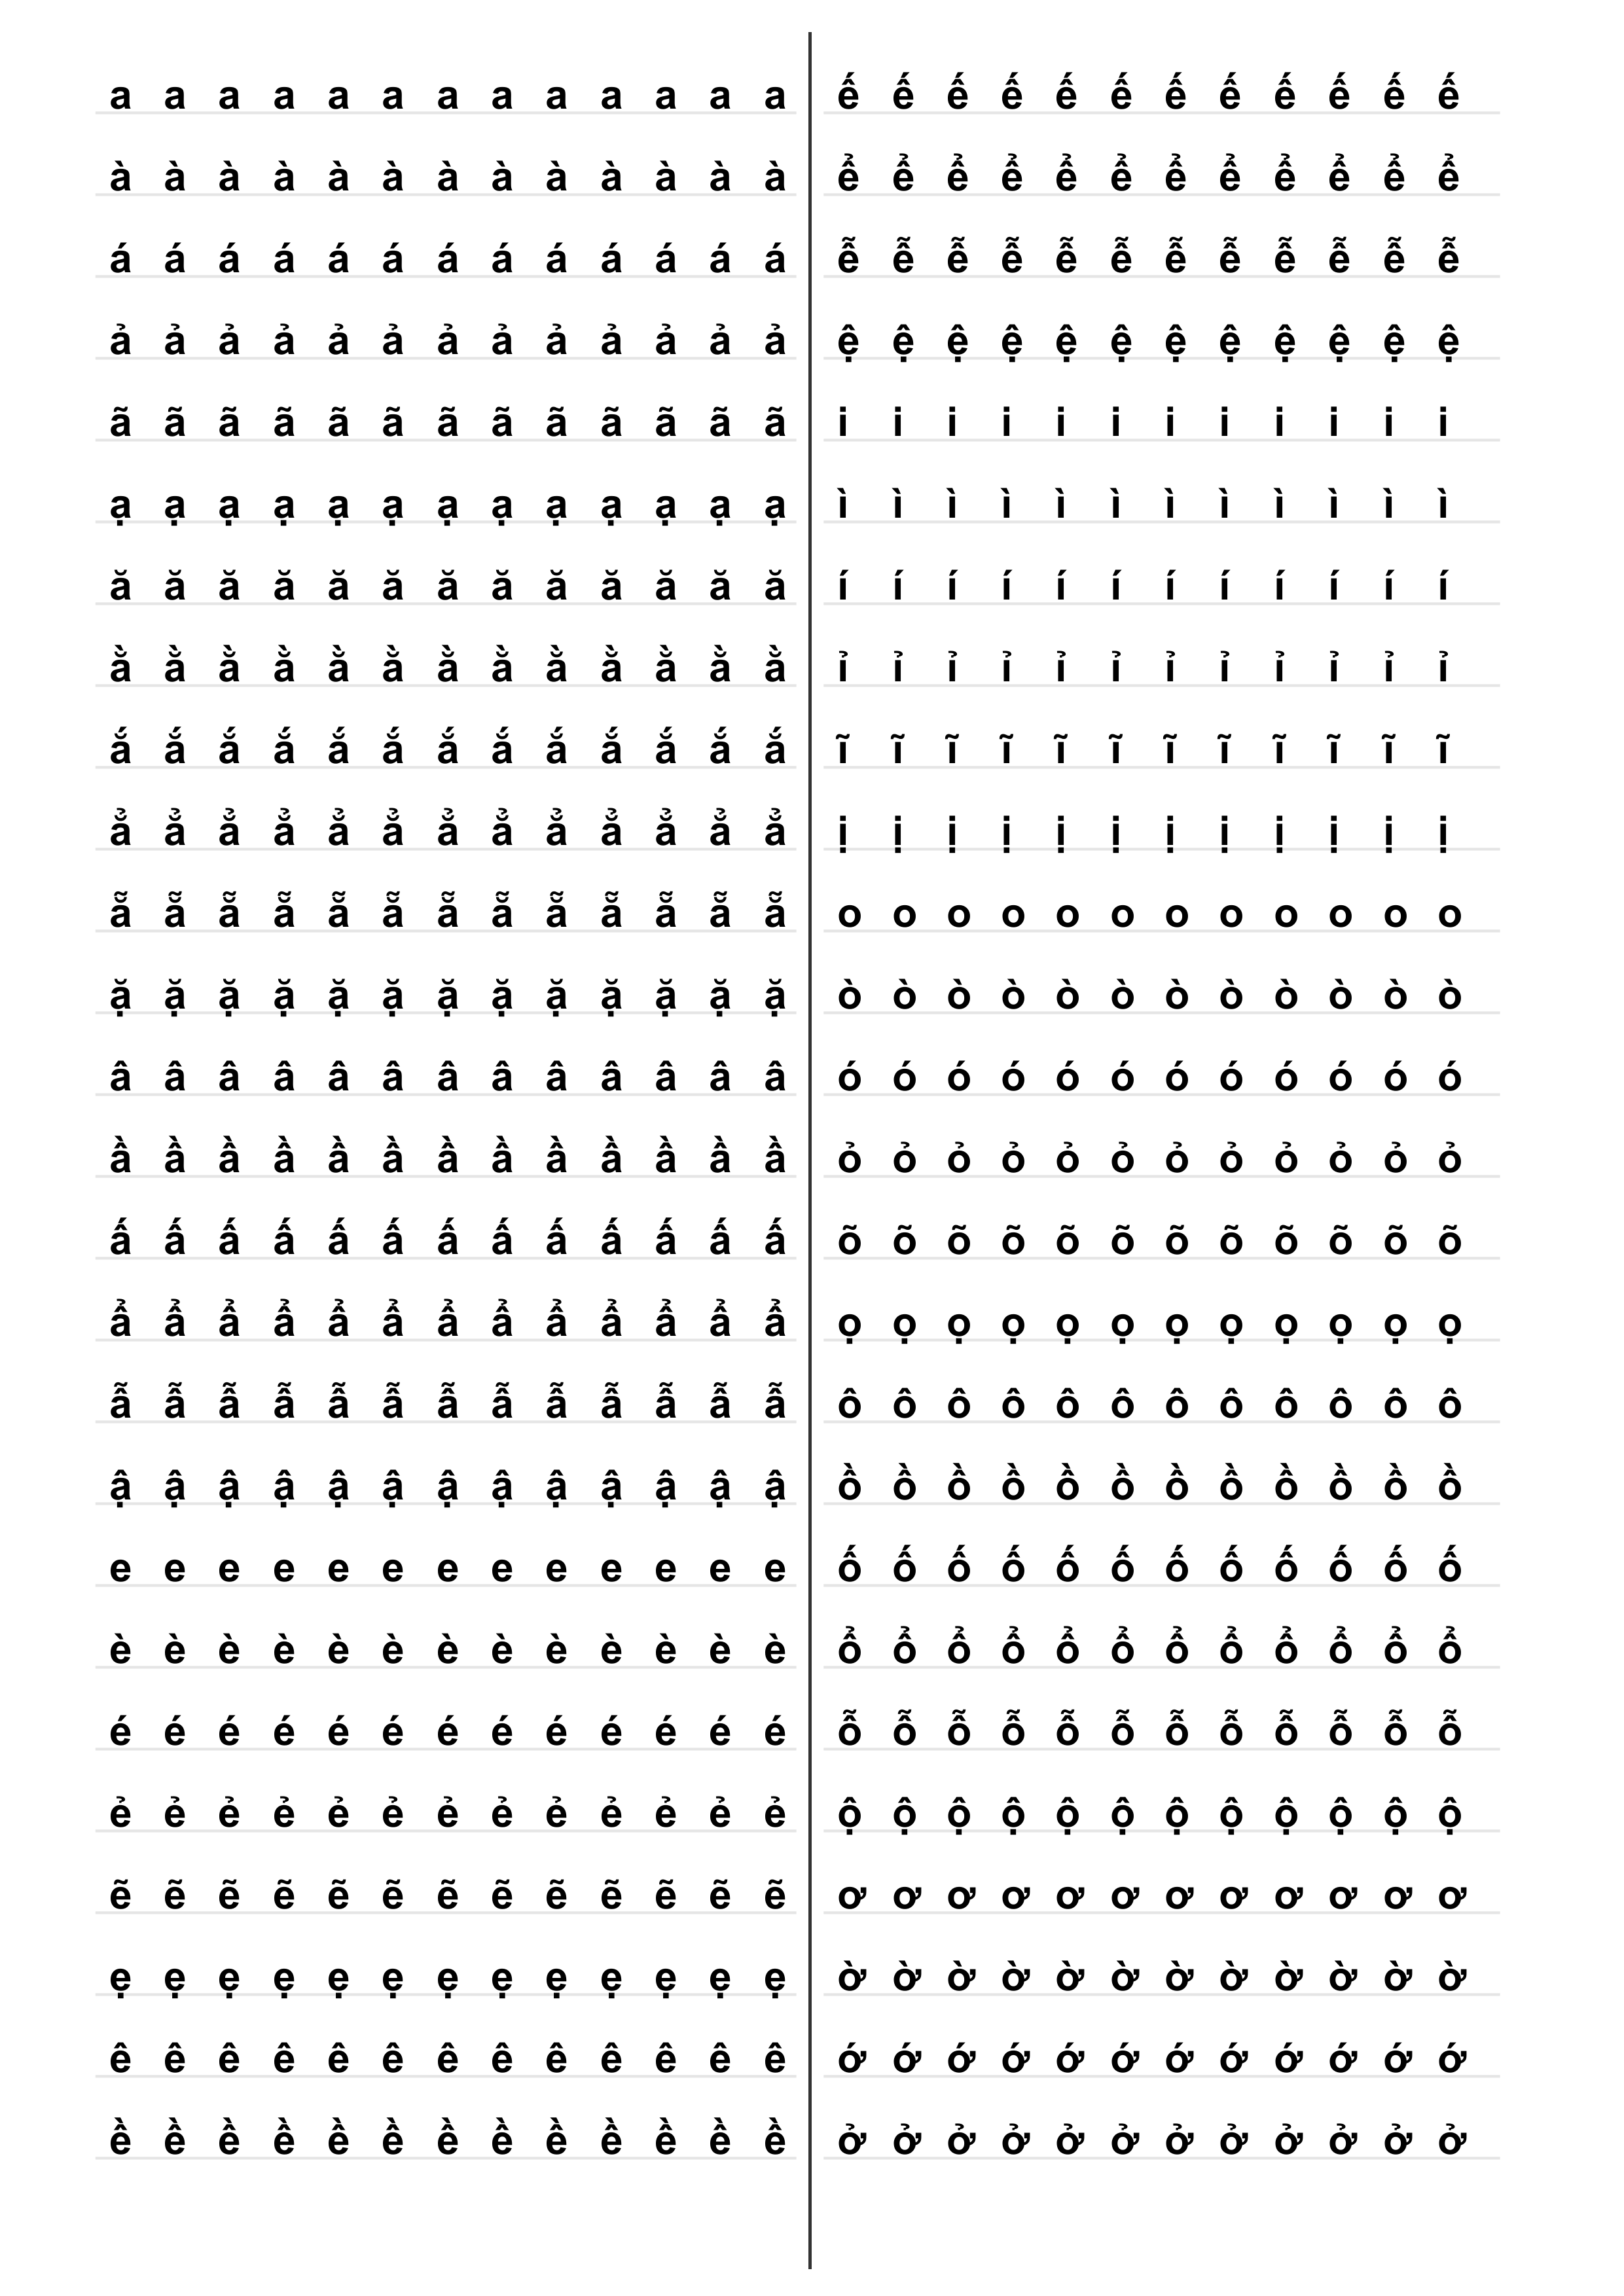

In [7]:
pdf_path = create_vietnamese_sheet_all_bold(str(FONT_PATH), cfg, REF_TEXT)
print(f"Saved PDF: {pdf_path}")

png_files = sorted(pdf_path.parent.glob(f"{pdf_path.stem}_page_*.png"))
print("Generated PNG pages:")
for p in png_files:
    print(" -", p)

if png_files:
    display(Image(filename=str(png_files[0])))